# `Genesis` demo — mobile dual-arm FR3 

This notebook shows how to use the reusable `RobotScene` class from
`scripts/scene_robot_tables.py`:

1. **Start** the simulation environment
2. **Drive the base** around the scene (forward / strafe / rotate)
3. **Control individual joints** (arms + grippers)
4. **Use IK** to move the left / right arm end-effectors

## 1. Start the simulation

Toggle **`HEADLESS`** below:
* `HEADLESS = True` — no viewer window; you only see the inline frames (`show()`) and the
  final mp4. This is the right choice for a remote/browser kernel with no display.
* `HEADLESS = False` — opens the native Genesis viewer window (a separate desktop window;
  it does **not** appear inside the browser). Requires a display (`DISPLAY` set). The inline
  `show()` frames and the mp4 still work in addition to the window.

In [ ]:
import os, sys
import numpy as np
import cv2
import ipywidgets as widgets
from IPython.display import display
from sidecar import Sidecar

# Make the script importable from this notebook.
sys.path.insert(0, os.path.abspath("../scripts"))

from scene_robot_tables import RobotScene

# Toggle this: True = no viewer window (offscreen only),
#              False = also open the native Genesis viewer (needs a display).
HEADLESS = True

sim = RobotScene(headless=HEADLESS, save_video=True)

# --- live view: stream both cameras into a Sidecar panel ---
# Two JPEG image widgets (top-down + head camera); show() pushes the latest
# frame from each camera into them. Works regardless of HEADLESS.
_sc = Sidecar(title="Robot Visualizer")
_top_widget = widgets.Image(format="jpeg")
_head_widget = widgets.Image(format="jpeg")
with _sc:
    display(widgets.VBox([
        widgets.Label("Top-down view"), _top_widget,
        widgets.Label("Head camera"), _head_widget,
    ]))


def _to_jpeg(rgb):
    """Encode an RGB frame to JPEG bytes for an ipywidgets.Image."""
    _, buf = cv2.imencode(".jpg", rgb[:, :, ::-1])  # RGB -> BGR for cv2
    return buf.tobytes()


def show(title=None):
    """Stream the current top-down and head-camera frames to the Sidecar."""
    _top_widget.value = _to_jpeg(sim.render())
    _head_widget.value = _to_jpeg(sim.render_head())


sim.start_recording()   # begin accumulating frames for the final mp4
show("initial scene")

## 2. Drive the base

`sim.set_base_velocity(vx, vy, wz, steps)` sets a body-frame velocity and advances the simulation:
* `vx` — forward (+) / back (−), m/s
* `vy` — strafe left (+) / right (−), m/s
* `wz` — rotate in place, left (+) / right (−), rad/s

The dual-steer wheels and a heading-hold controller are handled internally.

start base pose: [-0.   4.5 -0. ]


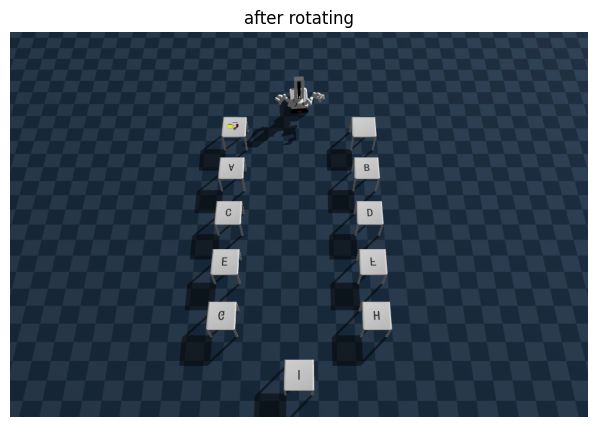

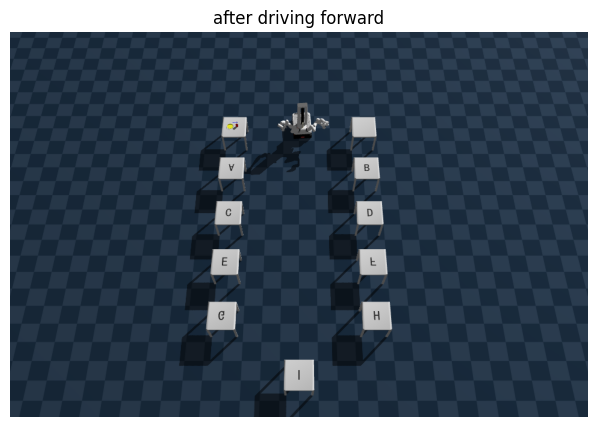

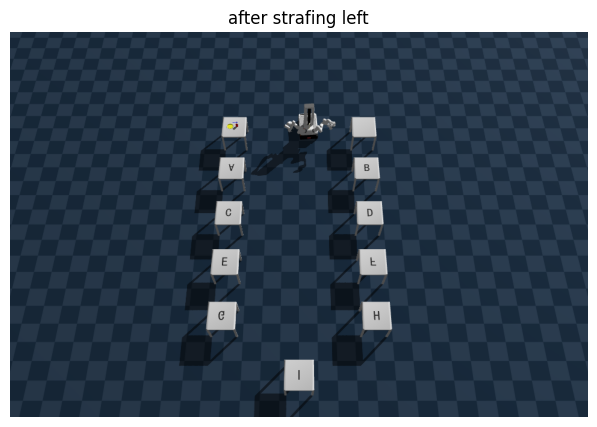

end base pose: [ 0.291  3.448 -0.   ] yaw(deg): -85.8


In [2]:
print("start base pose:", np.round(sim.get_base_pose()[0], 3))

sim.set_base_velocity(0.0, 0.0, -1.2, steps=320)   # rotate in place (left)
sim.stop_base(steps=20)
show("after rotating")

sim.set_base_velocity(0.5, 0.0, 0.0, steps=500)   # forward
show("after driving forward")

sim.set_base_velocity(0.0, 0.5, 0.0, steps=150)   # strafe left
show("after strafing left")


pos, yaw = sim.get_base_pose()
print("end base pose:", np.round(pos, 3), "yaw(deg):", round(np.degrees(yaw), 1))

## 3. Control individual joints

Each arm has 7 joints and a 2-finger gripper. Set position targets directly:
* `sim.set_arm(side, q)` — 7 joint angles (rad) for `side` in `'left'` / `'right'`
* `sim.set_gripper(side, opening)` — finger opening in meters (`0.0` closed .. `0.04` open)

Targets are held every simulation step; pass `step=True, steps=N` to advance immediately.

left arm q (rad): [-0.   -1.5   0.   -2.2   0.    1.5   0.79]


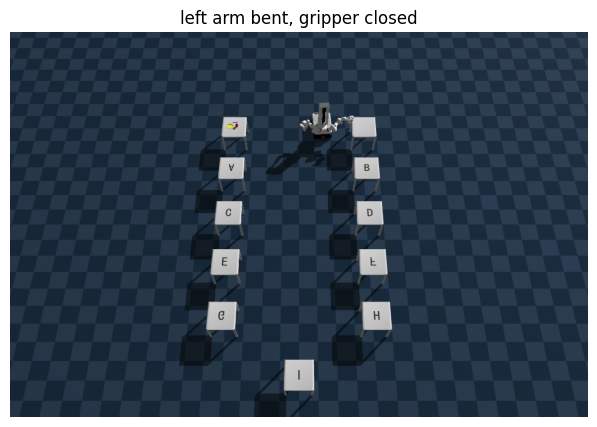

In [3]:
# Read the current left-arm joint angles, then bend joint 4 (elbow) and joint 6 (wrist).
q_left = sim.get_arm("left").copy()
print("left arm q (rad):", np.round(q_left, 2))

q_left[3] += 0.6    # joint4
q_left[5] -= 0.5    # joint6
sim.set_arm("left", q_left, step=True, steps=120)

# Close then open the left gripper.
sim.set_gripper("left", 0.0, step=True, steps=80)    # close
show("left arm bent, gripper closed")
sim.set_gripper("left", 0.04, step=True, steps=80)   # open again

## 4. Move the end-effectors with IK

`sim.move_ee(side, pos, quat=DOWN, n_waypoints, settle)` solves inverse kinematics for
one arm and moves its **finger tool-center-point (TCP)** to a world-frame `pos` along an
interpolated straight line. `quat` is the gripper orientation (default: pointing down).

We pick targets **relative to each arm's current TCP** so they are reachable. Use
`sim.get_ee_pos(side)` to read the current TCP, and `sim.ik(side, pos)` if you just want
the joint angles without moving.

left: TCP [1.791 3.155 0.835] -> target [1.871 3.155 0.715]


   IK q (rad): [ 0.8  -1.14  0.7  -1.67  0.87  1.77 -0.24]
   reached [1.862 3.143 0.792]  err=0.078 m


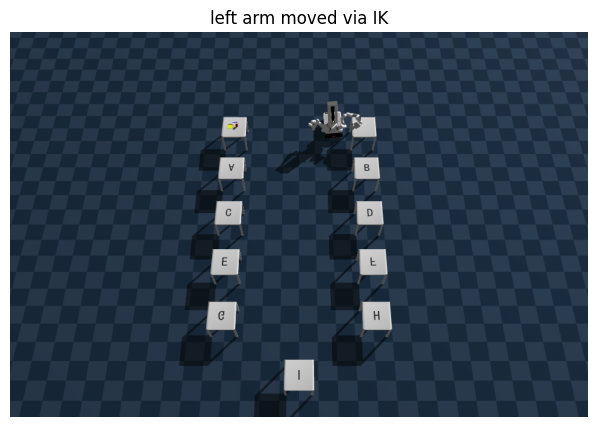

right: TCP [0.346 2.889 0.812] -> target [0.426 2.889 0.692]
   IK q (rad): [ 0.64 -1.75  0.16 -2.55 -1.55  0.44 -1.76]
   reached [0.457 2.866 0.716]  err=0.045 m


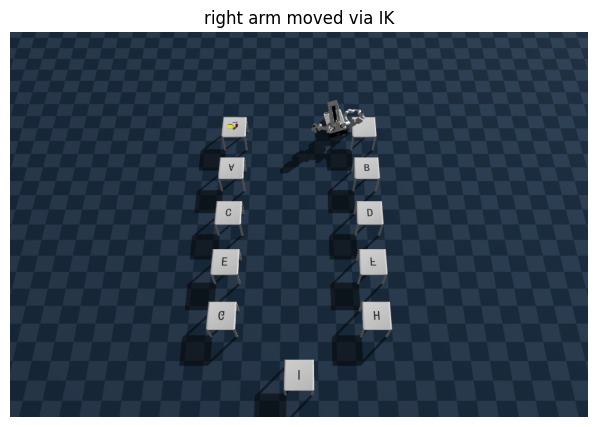

In [4]:
for side in ("left", "right"):
    tcp = sim.get_ee_pos(side)
    target = tcp + np.array([0.08, 0.0, -0.12])   # 8 cm forward, 12 cm down
    print(f"{side}: TCP {np.round(tcp, 3)} -> target {np.round(target, 3)}")

    q = sim.ik(side, tuple(target))               # IK solution (7 joint angles)
    print(f"   IK q (rad): {np.round(q, 2)}")

    sim.move_ee(side, tuple(target), n_waypoints=40)
    reached = sim.get_ee_pos(side)
    print(f"   reached {np.round(reached, 3)}  err={np.linalg.norm(reached - target):.3f} m")
    show(f"{side} arm moved via IK")

## 5. Save and embed the recorded video

Everything above was recorded (we called `start_recording()` in step 1). Write it to an
mp4 and embed it inline — the second way to visualize the run.

In [5]:
from IPython.display import Video

try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _HERE = os.path.abspath(".")

top_path, head_path = sim.save_video(os.path.join(_HERE, "videos", "robot_scene_demo.mp4"))
display(Video(top_path, embed=True, width=720))
display(Video(head_path, embed=True, width=720))

✓ Saved top-down video to /mnt/dev-tools/fr3-genesis/notebooks/videos/robot_scene_demo_top.mp4
✓ Saved head-camera video to /mnt/dev-tools/fr3-genesis/notebooks/videos/robot_scene_demo_head.mp4
